In [13]:
'''
Evaluate the performance of search algorithms 
Collect scores across all prompts and trials, and compute the overall statistics.
'''

import os, psutil, gc
import time
import re
import json
import pprint
import importlib

import logging
logging.basicConfig(format='%(message)s', level=logging.FATAL+1)

import random
import numpy as np
np.set_printoptions(precision=4)

from utils import metrics 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
sns.set_style("whitegrid")
sns.set_palette("tab20")
colors = sns.color_palette("bright")



-> config_name = mcts--level-4--q-079--q31--n-4--d-20--b-80--cpuct-2
(20, 400)
peak1b_score = 0.2500 (±0.0993)

-> config_name = mcts--level-4--q-079--q31--n-4--d-20--b-400--cpuct-2
(20, 400)
peak1b_score = 0.2500 (±0.0993)

-> config_name = mcts--level-4--q-079--q71--n-4--d-20--b-80--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True
(20, 400)
peak1b_score = 0.0000 (±0.0000)

-> config_name = mcts--level-4--q-079--q71--n-4--d-20--b-400--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True
(20, 400)
peak1b_score = 0.1000 (±0.0688)


[]

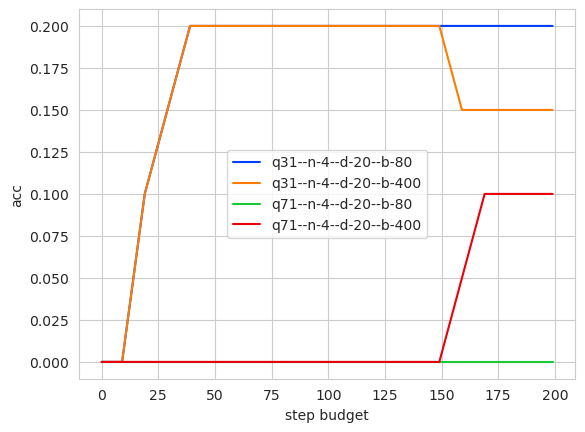

In [24]:

level = 4
num_trials = 20
step_budget = 400
step_idxes = np.linspace(0, 199, 21, dtype=int)

q_idx = 79

config_names = [
    f"mcts--level-4--q-079--q31--n-4--d-20--b-80--cpuct-2",
    f"mcts--level-4--q-079--q31--n-4--d-20--b-400--cpuct-2",
    f"mcts--level-4--q-079--q71--n-4--d-20--b-80--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
    f"mcts--level-4--q-079--q71--n-4--d-20--b-400--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True"
]

importlib.reload(metrics)

for cidx, config_name in enumerate(config_names):
    print(f"\n-> config_name = {config_name}")
    result_dir = f"results/mcts--level-{level}/prompts/q-{q_idx:03d}/{config_name}"    
    peak1b_correctnes_mean, peak1b_correctness_std = \
        metrics.compute_stats_correctness_curve_budget(result_dir, config_name, num_trials, step_budget)

    match = re.search(r'(q\d+--n-\d+--d-\d+--b-\d+)', config_name)
    if match:
        config_label = match.group(1)
    else:
        config_label = config_name
        
    plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes], color=colors[cidx], label=config_label) 
    # plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes] + peak1b_correctness_std[step_idxes], color=colors[cidx], alpha=0.4)
    # plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes] - peak1b_correctness_std[step_idxes], color=colors[cidx], alpha=0.4)

plt.ylabel(f"acc")
plt.xlabel(f"step budget")
# plt.xticks(step_idxes)
plt.legend()
plt.plot()